# Phase 2 - Clustering Implementation

This notebook applies KMeans and DBSCAN clustering.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

In [11]:
df = pd.read_csv("clean_data.csv")
df.head()

/tmp/ipykernel_12610/1576058867.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("clean_data.csv")


,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Gender_Female,Gender_Male,Department_Arts,Department_Business,Department_Engineering,Department_Medical,Department_Science,Total_Activity,Sleep_Study_Ratio,Activity_Per_Hour,Sleep_Deficit
0,0.536144,1.085677,0.289788,-0.861956,-0.093125,0.911792,0.751322,False,True,False,False,False,False,False,True,-0.719460,0.821735,-0.622490,-0.265947
1,-0.457414,-0.248048,-1.105638,1.296600,1.749418,1.558063,-1.846436,False,False,True,False,False,True,False,False,1.919321,-1.278335,1.566238,1.111099
2,-0.457414,0.290577,-1.198106,-1.747063,-1.226997,1.442658,-0.677106,False,False,True,False,False,False,True,False,-2.495744,1.381698,-3.060133,1.198436
3,0.053420,1.276453,0.786877,-2.065771,0.757279,1.281090,-0.677106,False,False,True,False,False,True,False,False,-0.775821,2.763078,-0.685405,-0.784305
4,-0.999528,0.514392,-0.054223,-1.456105,0.544678,-1.627130,1.240533,False,False,True,True,False,False,False,False,-0.608900,1.445965,-0.501439,0.084051


In [12]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87141 entries, 0 to 87140
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     87141 non-null  float64
 1   CGPA                    87141 non-null  object 
 2   Sleep_Duration          87141 non-null  float64
 3   Study_Hours             87141 non-null  float64
 4   Social_Media_Hours      87141 non-null  float64
 5   Physical_Activity       87141 non-null  float64
 6   Stress_Level            87141 non-null  float64
 7   Depression              87141 non-null  bool   
 8   Gender_Female           87141 non-null  bool   
 9   Gender_Male             87141 non-null  bool   
 10  Department_Arts         87141 non-null  bool   
 11  Department_Business     87141 non-null  bool   
 12  Department_Engineering  87141 non-null  bool   
 13  Department_Medical      87141 non-null  bool   
 14  Department_Science      87141 non-null

In [13]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Keep only numeric columns
df_model = df.select_dtypes(include=np.number)

# Remove missing values if any
df_model = df_model.dropna()

# Scale data
scaler = StandardScaler()
X = scaler.fit_transform(df_model)
print(df_model.shape)

(87141, 10)


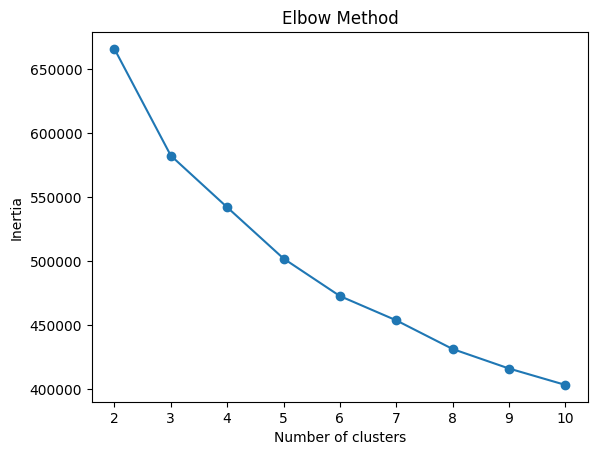

In [14]:
inertia = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [15]:
# Optimal k chosen using Elbow Method
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X)

df['Cluster_KMeans'] = labels_kmeans

In [17]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)

df['Cluster_DBSCAN'] = labels_dbscan
print(np.unique(labels_dbscan))

[-1  0]


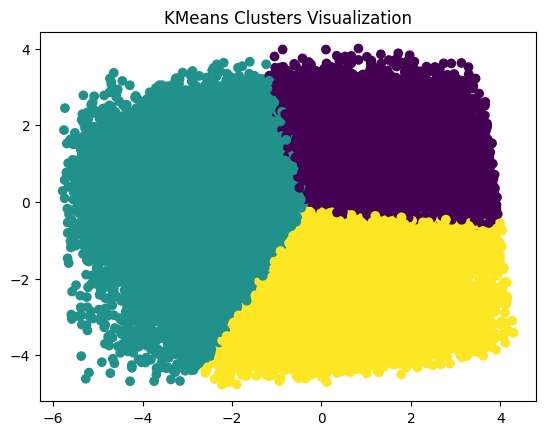

In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans)
plt.title("KMeans Clusters Visualization")
plt.show()

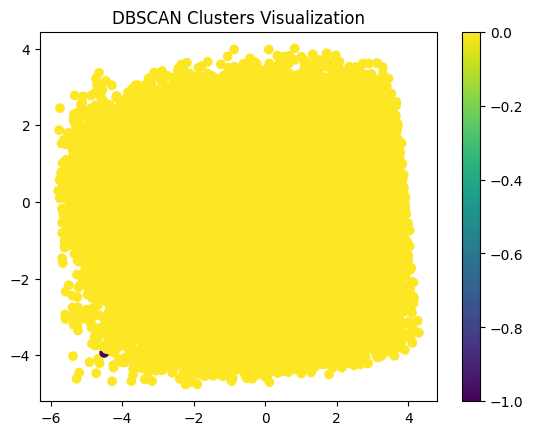

In [21]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_dbscan, cmap='viridis')
plt.title("DBSCAN Clusters Visualization")
plt.colorbar()
plt.show()

In [ ]:
df.to_csv("clustering_results.csv", index=False)